Validation: fixed-fixed beam, P=-10000 N at midspan
Solved OK.  Max nodal deflection: 2.6042e-01 m

--- Support reactions ---
  Node   0  vertical force (N)    R = +5000.0000
  Node   0  moment (N·m)         R = +12500.0000
  Node  40  vertical force (N)    R = +5000.0000
  Node  40  moment (N·m)         R = -12500.0000

M(x=0)   = -12500.00  N·m   (expected -12500.00)
M(x=5)   = +12497.50  N·m   (expected +12500.00)
M(x=10)  = -0.00  N·m   (expected -12500.00)
V(x=0+)  = +5000.00  N     (expected  +5000.00)
V(x=10-) = -5000.00  N     (expected  -5000.00)

Example: cantilever with mixed loads
Solved OK.  Max nodal deflection: 6.7797e-02 m

--- Support reactions ---
  Node   0  vertical force (N)    R = +1063.8000
  Node   0  moment (N·m)         R = +2844.0000
  Node  40  vertical force (N)    R = +1936.2000
  Node  40  moment (N·m)         R = -4206.0000



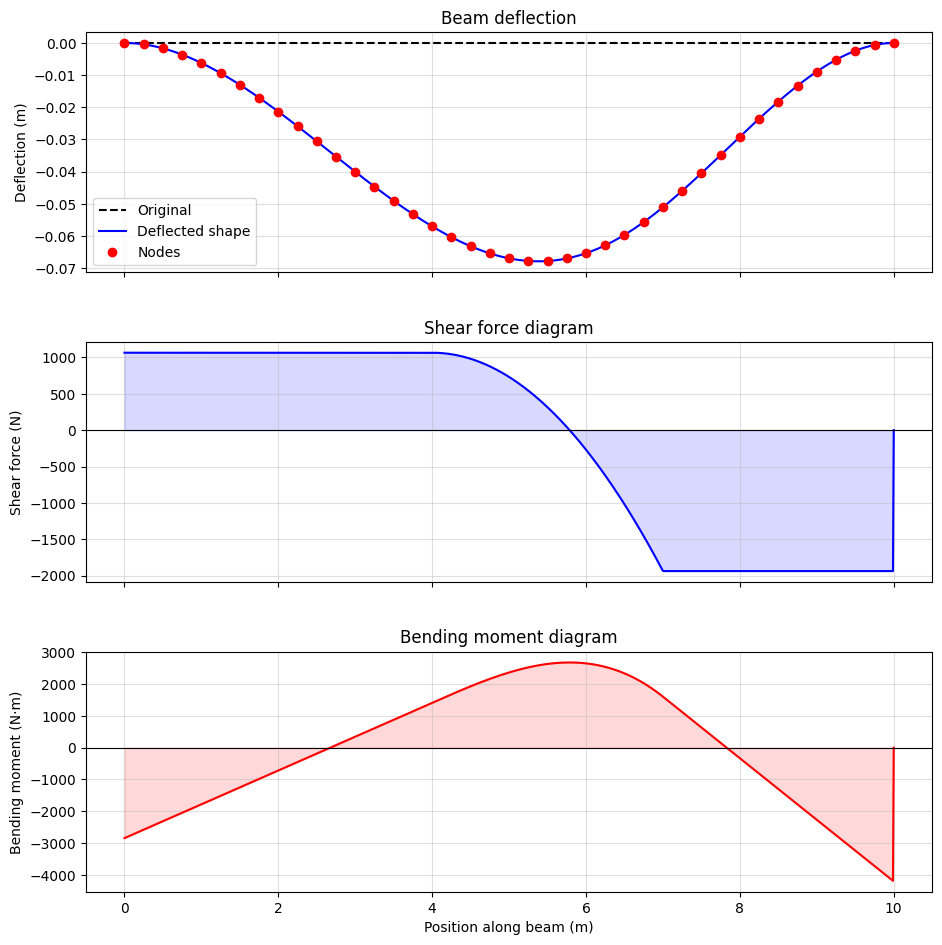

In [17]:
import numpy as np
import matplotlib.pyplot as plt


class BeamFEA:
    def __init__(self, L, n_elem, E, I):
        """
        Initialize the beam FEA solver.

        Parameters
        ----------
        L      : float  Total beam length (m)
        n_elem : int    Number of elements
        E      : float  Young's modulus (Pa)
        I      : float  Second moment of area (m^4)
        """
        if L <= 0:
            raise ValueError("Beam length L must be positive.")
        if n_elem < 1:
            raise ValueError("n_elem must be at least 1.")
        if E <= 0 or I <= 0:
            raise ValueError("E and I must be positive.")

        self.L = L
        self.n_elem = n_elem
        self.l = L / n_elem          # uniform element length
        self.E = E
        self.I = I

        self.n_dof = 2 * (n_elem + 1)
        self.K = np.zeros((self.n_dof, self.n_dof))
        self.F = np.zeros(self.n_dof)
        self.U = np.zeros(self.n_dof)

        self.point_loads = []
        self.distributed_loads = []
        self.fixed_dofs = []

        self.is_solved = False
        self._assemble_stiffness()

    # ------------------------------------------------------------------
    # Stiffness assembly
    # ------------------------------------------------------------------
    def _assemble_stiffness(self):
        """Build the global stiffness matrix from Hermite cubic elements."""
        l, E, I = self.l, self.E, self.I

        K_e = E * I / l ** 3 * np.array([
            [12,      6 * l,    -12,      6 * l   ],
            [6 * l,   4 * l**2, -6 * l,   2 * l**2],
            [-12,    -6 * l,    12,       -6 * l   ],
            [6 * l,   2 * l**2, -6 * l,   4 * l**2],
        ])

        for i in range(self.n_elem):
            dofs = [2 * i, 2 * i + 1, 2 * i + 2, 2 * i + 3]
            self.K[np.ix_(dofs, dofs)] += K_e

    # ------------------------------------------------------------------
    # Load / BC definition
    # ------------------------------------------------------------------
    def add_point_load(self, mag, position):
        """
        Add a concentrated transverse force.

        Parameters
        ----------
        mag      : float  Force magnitude (N). Negative = downward.
        position : float  x-coordinate along beam (0 <= position <= L).
        """
        if not (0.0 <= position <= self.L):
            raise ValueError(
                f"Point load position {position} is outside beam [0, {self.L}]."
            )
        self.point_loads.append({'mag': mag, 'pos': position})

    def add_distributed_load(self, w1, w2, start_pos, end_pos):
        """
        Add a distributed load (UDL if w1==w2, UVL otherwise).

        Parameters
        ----------
        w1, w2    : float  Intensity at start and end (N/m). Negative = downward.
        start_pos : float  Start x-coordinate (>= 0).
        end_pos   : float  End   x-coordinate (<= L, strictly > start_pos).
        """
        if start_pos < 0 or end_pos > self.L:
            raise ValueError(
                f"Distributed load span [{start_pos}, {end_pos}] is outside beam [0, {self.L}]."
            )
        if end_pos <= start_pos:
            raise ValueError("end_pos must be strictly greater than start_pos.")
        self.distributed_loads.append(
            {'w1': w1, 'w2': w2, 'start': start_pos, 'end': end_pos}
        )

    def set_fixed_dofs(self, dofs):
        """
        Specify which DOFs are fully restrained (support definition).

        Convention
        ----------
        Even DOF 2*n  : vertical displacement at node n is zero.
        Odd  DOF 2*n+1: rotation at node n is zero.

        Parameters
        ----------
        dofs : list[int]  Global DOF indices to restrain.
        """
        for d in dofs:
            if not (0 <= d < self.n_dof):
                raise ValueError(f"DOF {d} is out of range [0, {self.n_dof - 1}].")
        self.fixed_dofs = list(dofs)

    # ------------------------------------------------------------------
    # Solver
    # ------------------------------------------------------------------
    def solve(self):
        """Apply loads, enforce BCs, and solve K_ff * U_f = F_f."""
        self.F[:] = 0.0

        # ---- 1. Point loads → equivalent nodal forces ----------------
        for load in self.point_loads:
            mag, pos = load['mag'], load['pos']
            remainder = pos % self.l

            # Check both remainder ≈ 0 and remainder ≈ l to handle float drift
            on_node = (
                np.isclose(remainder, 0.0,     atol=1e-9) or
                np.isclose(remainder, self.l,   atol=1e-9)
            )

            if on_node:
                node_idx = int(round(pos / self.l))
                self.F[2 * node_idx] += mag
            else:
                left_idx = int(pos // self.l)
                a = pos - left_idx * self.l
                b = self.l - a

                # Standard Hermite fixed-end force formulas
                self.F[2 * left_idx]     += mag * b**2 * (3 * a + b) / self.l**3
                self.F[2 * left_idx + 1] += mag * a * b**2             / self.l**2
                self.F[2 * left_idx + 2] += mag * a**2 * (3 * b + a)   / self.l**3
                self.F[2 * left_idx + 3] += -mag * a**2 * b             / self.l**2

        # ---- 2. Distributed loads (UDL / UVL) via Gauss quadrature --
        gauss_weights = np.array([5 / 9, 8 / 9, 5 / 9])
        gauss_pts     = np.array([-np.sqrt(3 / 5), 0.0, np.sqrt(3 / 5)])

        for load in self.distributed_loads:
            w1, w2  = load['w1'], load['w2']
            w_start = load['start']
            w_end   = load['end']
            L_load  = w_end - w_start   # guaranteed > 0 by add_distributed_load

            for i in range(self.n_elem):
                x_left  = i * self.l
                x_right = x_left + self.l

                overlap_start = max(x_left,  w_start)
                overlap_end   = min(x_right, w_end)
                if overlap_start >= overlap_end:
                    continue

                a = overlap_start - x_left
                b = overlap_end   - x_left

                jac       = (b - a) / 2.0
                xi_mapped = jac * gauss_pts + (b + a) / 2.0   # local coords in [0, l]
                x_global  = xi_mapped + x_left

                # Linearly varying intensity at each Gauss point
                w_gp = w1 + (w2 - w1) * ((x_global - w_start) / L_load)

                # Hermite shape functions (xi is local coordinate in [0, l])
                xi = xi_mapped
                N1 = 1 - 3 * (xi / self.l)**2 + 2 * (xi / self.l)**3
                N2 = xi * (1 - 2 * (xi / self.l) + (xi / self.l)**2)
                N3 = 3 * (xi / self.l)**2 - 2 * (xi / self.l)**3
                N4 = xi * ((xi / self.l)**2 - (xi / self.l))

                self.F[2 * i]     += np.dot(gauss_weights, w_gp * N1) * jac
                self.F[2 * i + 1] += np.dot(gauss_weights, w_gp * N2) * jac
                self.F[2 * i + 2] += np.dot(gauss_weights, w_gp * N3) * jac
                self.F[2 * i + 3] += np.dot(gauss_weights, w_gp * N4) * jac

        # ---- 3. Boundary conditions (free-DOF partitioning) ----------
        if not self.fixed_dofs:
            raise RuntimeError("No supports defined. Add at least one fixed DOF.")

        free_dofs = [i for i in range(self.n_dof) if i not in self.fixed_dofs]
        K_ff = self.K[np.ix_(free_dofs, free_dofs)]
        F_f  = self.F[free_dofs]

        # Guard against singular systems (rigid-body modes)
        rank = np.linalg.matrix_rank(K_ff)
        if rank < len(free_dofs):
            raise RuntimeError(
                f"Stiffness matrix is singular (rank {rank} < {len(free_dofs)}). "
                "Check that supports eliminate all rigid-body modes."
            )

        # ---- 4. Solve -------------------------------------------------
        U_f = np.linalg.solve(K_ff, F_f)
        self.U[free_dofs] = U_f

        # ---- 5. Recover full internal force vector --------------------
        self.F_total = self.K @ self.U
        self.is_solved = True

        max_def = np.max(np.abs(self.U[0::2]))
        print(f"Solved OK.  Max nodal deflection: {max_def:.4e} m")

    # ------------------------------------------------------------------
    # Post-processing helpers
    # ------------------------------------------------------------------
    def _compute_diagrams(self, n_pts=1000):
        """
        Compute SFD and BMD by equilibrium integration from the left.

        Sign convention (standard beam theory)
        ---------------------------------------
        V positive : net upward force to the left of the cut.
        M positive : sagging (bottom fibre in tension).

        Key sign rule for moment reactions
        -----------------------------------
        The FEA nodal moment reaction R = F_total[odd_dof] - F[odd_dof] is
        in the global DOF sense (positive = CCW couple applied BY support ON beam).
        When accumulated into M(x) from the left, a CCW support moment opposes
        sagging, so it enters with a NEGATIVE sign:
            M(x) += R_vertical * (x - x_sup)    [force contribution]
            M(x) -= R_moment                     [moment contribution — note minus]
        """
        x = np.linspace(0, self.L, n_pts)
        V = np.zeros(n_pts)
        M = np.zeros(n_pts)

        for dof in self.fixed_dofs:
            reaction = float(self.F_total[dof] - self.F[dof])

            if dof % 2 == 0:
                # Vertical reaction: contributes to both V and M
                x_sup = (dof // 2) * self.l
                mask  = x >= x_sup
                V[mask] += reaction
                M[mask] += reaction * (x[mask] - x_sup)

            else:
                # Moment reaction: contributes to M only, with NEGATIVE sign.
                # The FEA reaction is the CCW couple the support applies on the beam.
                # In the left-to-right equilibrium walk, this opposes sagging → subtract.
                x_sup = ((dof - 1) // 2) * self.l
                mask  = x >= x_sup
                M[mask] -= reaction

        for load in self.point_loads:
            mag, pos = load['mag'], load['pos']
            mask = x > pos
            V[mask] += mag
            M[mask] += mag * (x[mask] - pos)

        for load in self.distributed_loads:
            w1, w2  = load['w1'], load['w2']
            start, end = load['start'], load['end']
            L_load  = end - start

            x_local = np.clip(x - start, 0.0, L_load)
            w_local = w1 + (w2 - w1) * (x_local / L_load)

            # Rectangular (uniform w1) + triangular (Δw) decomposition
            F_rect = w1 * x_local
            F_tri  = 0.5 * (w_local - w1) * x_local

            V += F_rect + F_tri
            M += F_rect * (x - (start + x_local / 2))
            M += F_tri  * (x - (start + 2 * x_local / 3))

        return x, V, M

    def _deflection_curve(self, pts_per_elem=20):
        """Reconstruct the deflection curve using Hermite shape functions."""
        x_out, v_out = [], []
        for i in range(self.n_elem):
            v1,  th1 = self.U[2 * i],     self.U[2 * i + 1]
            v2,  th2 = self.U[2 * i + 2], self.U[2 * i + 3]
            xi = np.linspace(0, self.l, pts_per_elem)

            N1 = 1 - 3 * (xi / self.l)**2 + 2 * (xi / self.l)**3
            N2 = xi * (1 - 2 * (xi / self.l) + (xi / self.l)**2)
            N3 = 3 * (xi / self.l)**2 - 2 * (xi / self.l)**3
            N4 = xi * ((xi / self.l)**2 - (xi / self.l))

            x_out.append(xi + i * self.l)
            v_out.append(N1 * v1 + N2 * th1 + N3 * v2 + N4 * th2)

        return np.concatenate(x_out), np.concatenate(v_out)

    def plot_results(self):
        """Plot deflection, SFD, and BMD in a single figure."""
        if not self.is_solved:
            raise RuntimeError("Call .solve() before .plot_results().")

        x_def, v_def   = self._deflection_curve()
        x_diag, V, M   = self._compute_diagrams()

        fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
        fig.tight_layout(pad=4.0)

        # Deflection
        x_nodes = np.linspace(0, self.L, self.n_elem + 1)
        axs[0].plot(x_nodes, np.zeros_like(x_nodes), 'k--', label='Original')
        axs[0].plot(x_def,   v_def, 'b-', label='Deflected shape')
        axs[0].plot(x_nodes, self.U[0::2], 'ro', label='Nodes', zorder=5)
        axs[0].set_ylabel('Deflection (m)')
        axs[0].set_title('Beam deflection')
        axs[0].grid(True, alpha=0.4)
        axs[0].legend()

        # SFD
        axs[1].plot(x_diag, V, 'b-')
        axs[1].fill_between(x_diag, V, 0, color='blue', alpha=0.15)
        axs[1].axhline(0, color='black', linewidth=0.8)
        axs[1].set_ylabel('Shear force (N)')
        axs[1].set_title('Shear force diagram')
        axs[1].grid(True, alpha=0.4)

        # BMD
        axs[2].plot(x_diag, M, 'r-')
        axs[2].fill_between(x_diag, M, 0, color='red', alpha=0.15)
        axs[2].axhline(0, color='black', linewidth=0.8)
        axs[2].set_ylabel('Bending moment (N·m)')
        axs[2].set_xlabel('Position along beam (m)')
        axs[2].set_title('Bending moment diagram')
        axs[2].grid(True, alpha=0.4)

        plt.show()

    # ------------------------------------------------------------------
    # Reaction utilities
    # ------------------------------------------------------------------
    def get_reactions(self):
        """
        Return support reactions as a dict {dof: value}.

        Positive vertical reaction = upward force (N).
        Positive moment reaction   = CCW (N·m).
        """
        if not self.is_solved:
            raise RuntimeError("Call .solve() first.")
        return {dof: float(self.F_total[dof] - self.F[dof])
                for dof in self.fixed_dofs}

    def print_reactions(self):
        """Print a formatted reaction summary."""
        reactions = self.get_reactions()
        print("\n--- Support reactions ---")
        for dof, R in reactions.items():
            node = dof // 2
            kind = "vertical force (N)  " if dof % 2 == 0 else "moment (N·m)       "
            print(f"  Node {node:3d}  {kind}  R = {R:+.4f}")
        print()


# =============================================================================
# Validation: fixed-fixed beam, midspan point load
# Analytical: M_A = M_B = -P*L/8 = +12500 N·m (hogging → negative in sagging convention)
#             M_mid = +P*L/8 = +12500 N·m (sagging)
#             R_A = R_B = P/2 = 5000 N (upward)
# =============================================================================
def _validate_fixed_fixed():
    print("=" * 55)
    print("Validation: fixed-fixed beam, P=-10000 N at midspan")
    print("=" * 55)
    beam = BeamFEA(L=10, n_elem=40, E=200e9, I=1e-6)
    beam.set_fixed_dofs([0, 1, 80, 81])
    beam.add_point_load(mag=-10000, position=5.0)
    beam.solve()
    beam.print_reactions()

    x, V, M = beam._compute_diagrams(n_pts=10000)
    i_mid = np.argmin(np.abs(x - 5.0))

    print(f"M(x=0)   = {M[0]:+.2f}  N·m   (expected -12500.00)")
    print(f"M(x=5)   = {M[i_mid]:+.2f}  N·m   (expected +12500.00)")
    print(f"M(x=10)  = {M[-1]:+.2f}  N·m   (expected -12500.00)")
    print(f"V(x=0+)  = {V[1]:+.2f}  N     (expected  +5000.00)")
    print(f"V(x=10-) = {V[-2]:+.2f}  N     (expected  -5000.00)")
    print()


# =============================================================================
# Example from original code: cantilever + point load + UDL + UVL
# =============================================================================
if __name__ == "__main__":
    _validate_fixed_fixed()

    print("=" * 55)
    print("Example: cantilever with mixed loads")
    print("=" * 55)
    beam = BeamFEA(L=10, n_elem=40, E=200e9, I=1e-6)
    beam.set_fixed_dofs([0, 1,80,81])                                   # clamped at x=0

    # beam.add_point_load(mag=-5000, position=8)
    # beam.add_distributed_load(w1=-1000, w2=-1000, start_pos=0, end_pos=10)
    beam.add_distributed_load(w1=0,     w2=-2000, start_pos=4, end_pos=7)

    beam.solve()
    beam.print_reactions()
    beam.plot_results()